In [1]:
# Imports
import polars as pl
from matplotlib import pyplot as plt
%matplotlib inline
import glob

In [2]:
# Import robot timestamp results
# Get all CSV files from the directory
moderate_load_files = glob.glob("../timestamp_results/thesis-eval-experiments/moderate-load/robot-states-#1/*.csv")
high_load_files = glob.glob("../timestamp_results/thesis-eval-experiments/high-load/robot-states-#1/*.csv")
# Read and combine all CSV files
dfs = [pl.read_csv(file, has_header=True, separator=',') for file in moderate_load_files]
moderate_load_df = pl.concat(dfs)
dfs = [pl.read_csv(file, has_header=True, separator=',') for file in high_load_files]
high_load_df = pl.concat(dfs)

# Import completed order timestamp files
moderate_load_completed_file = glob.glob("../timestamp_results/thesis-eval-experiments/moderate-load/kitchen-states-#1/*completed*.csv")
high_load_completed_file = glob.glob("../timestamp_results/thesis-eval-experiments/high-load/kitchen-states-#1/*completed*.csv")
# Import received order timestamp files
moderate_load_received_file = glob.glob("../timestamp_results/thesis-eval-experiments/moderate-load/kitchen-states-#1/*received*.csv")
high_load_received_file = glob.glob("../timestamp_results/thesis-eval-experiments/high-load/kitchen-states-#1/*received*.csv")
# Read and combine all CSV files
moderate_load_completed_df = pl.read_csv(moderate_load_completed_file[0], has_header=True, separator=',')
high_load_completed_df = pl.read_csv(high_load_completed_file[0], has_header=True, separator=',')
moderate_load_received_df = pl.read_csv(moderate_load_received_file[0], has_header=True, separator=',')
high_load_received_df = pl.read_csv(high_load_received_file[0], has_header=True, separator=',')

In [3]:
# Get t0 reference timestamp from received order timestamps for moderate load
t0_reference_moderate = moderate_load_received_df.filter(pl.col('ReceivedOrdersCount') == 1)['Timestamp'][0]
# Set t0 reference moderate load
moderate_load_df = moderate_load_df.with_columns(
    pl.when(pl.col('Timestamp') - t0_reference_moderate < 0).then(0).otherwise(pl.col('Timestamp') - t0_reference_moderate).alias('Timestamp')
)
moderate_load_completed_df = moderate_load_completed_df.with_columns(
    pl.when(pl.col('Timestamp') - t0_reference_moderate < 0).then(0).otherwise(pl.col('Timestamp') - t0_reference_moderate).alias('Timestamp')
)
moderate_load_received_df = moderate_load_received_df.with_columns(
    pl.when(pl.col('Timestamp') - t0_reference_moderate < 0).then(0).otherwise(pl.col('Timestamp') - t0_reference_moderate).alias('Timestamp')
)
# Get t0 reference timestamp from received order timestamps for high load
t0_reference_high = high_load_received_df.filter(pl.col('ReceivedOrdersCount') == 1)['Timestamp'][0]
# Set t0 reference high load
high_load_df = high_load_df.with_columns(
    pl.when(pl.col('Timestamp') - t0_reference_high < 0).then(0).otherwise(pl.col('Timestamp') - t0_reference_high).alias('Timestamp')
)
high_load_completed_df = high_load_completed_df.with_columns(
    pl.when(pl.col('Timestamp') - t0_reference_high < 0).then(0).otherwise(pl.col('Timestamp') - t0_reference_high).alias('Timestamp')
)
high_load_received_df = high_load_received_df.with_columns(
    pl.when(pl.col('Timestamp') - t0_reference_high < 0).then(0).otherwise(pl.col('Timestamp') - t0_reference_high).alias('Timestamp')
)

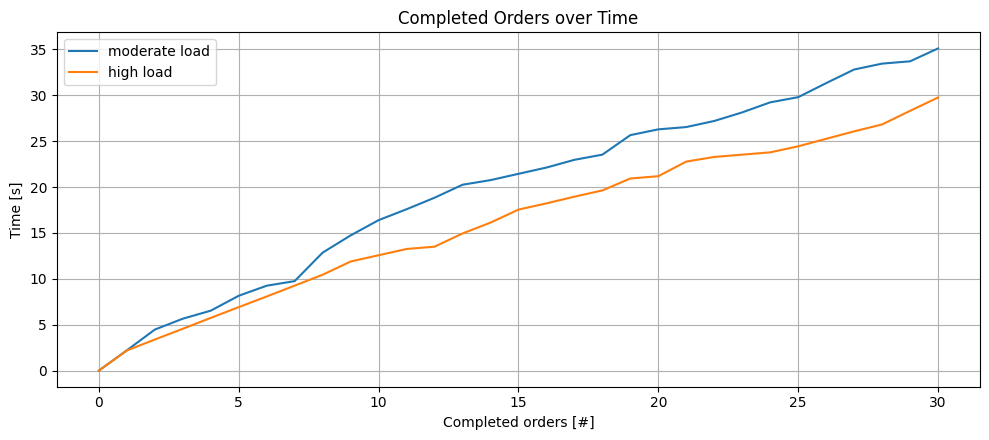

In [4]:
timestamp_dfs = [moderate_load_completed_df, high_load_completed_df]
labels = ['moderate load', 'high load']

# Plot all three with legend
plt.figure(figsize=(10, 4.5))
for timestamp_df,label in zip(timestamp_dfs,labels):
    plt.plot(timestamp_df['CompletedOrdersCount'], timestamp_df['Timestamp'] / 1e9, label=label)
plt.xlabel('Completed orders [#]')
plt.ylabel('Time [s]')
plt.title('Completed Orders over Time')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



In [6]:
# Get values using select() and .item() to extract scalars
makespan_moderate = moderate_load_completed_df.select(pl.col('Timestamp').max()).item() / 1e9
print("moderate load makespan: {0:.3f} s".format(makespan_moderate))

avg_interval_moderate = (
    moderate_load_completed_df
    .filter(pl.col('Timestamp') > 0)
    .select(pl.col('Timestamp').diff().mean())
    .item()
) / 1e9
print("moderate load average interval: {0:.3f} s".format(avg_interval_moderate))

makespan_high = high_load_completed_df.select(pl.col('Timestamp').max()).item() / 1e9
print("high load makespan: {0:.3f} s".format(makespan_high))

avg_interval_high = (
    high_load_completed_df
    .filter(pl.col('Timestamp') > 0)
    .select(pl.col('Timestamp').diff().mean())
    .item()
) / 1e9
print("high load average interval: {0:.3f} s".format(avg_interval_high))

moderate load makespan: 35.093 s
moderate load average interval: 1.134 s
high load makespan: 29.750 s
high load average interval: 0.950 s


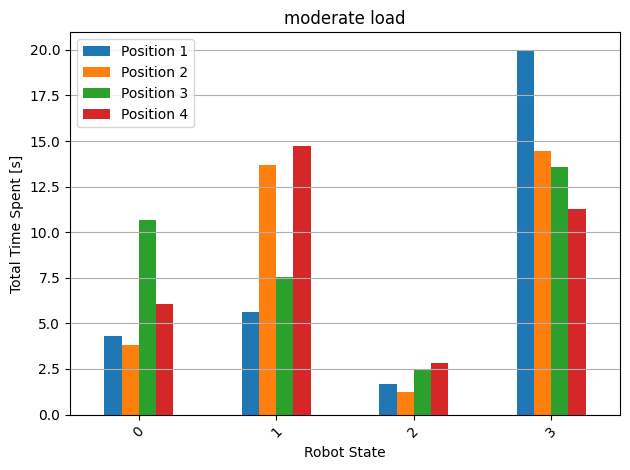

Total time recorded for Position 1: 31.566 seconds
Total utilized time for Position 1 (w/o IDLING and WAITING_FOR_PICKUP): 24.256 seconds (76.84%)
Total time recorded for Position 2: 33.189 seconds
Total utilized time for Position 2 (w/o IDLING and WAITING_FOR_PICKUP): 18.263 seconds (55.03%)
Total time recorded for Position 3: 34.281 seconds
Total utilized time for Position 3 (w/o IDLING and WAITING_FOR_PICKUP): 24.247 seconds (70.73%)
Total time recorded for Position 4: 34.843 seconds
Total utilized time for Position 4 (w/o IDLING and WAITING_FOR_PICKUP): 17.307 seconds (49.67%)


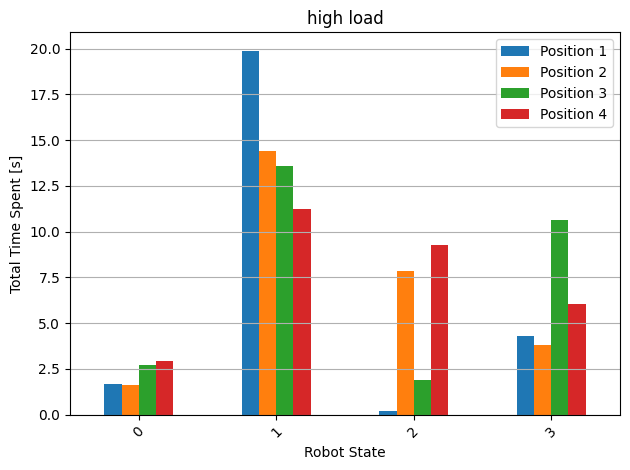

Total time recorded for Position 1: 26.062 seconds
Total utilized time for Position 1 (w/o IDLING and WAITING_FOR_PICKUP): 24.194 seconds (92.83%)
Total time recorded for Position 2: 27.685 seconds
Total utilized time for Position 2 (w/o IDLING and WAITING_FOR_PICKUP): 18.223 seconds (65.82%)
Total time recorded for Position 3: 28.777 seconds
Total utilized time for Position 3 (w/o IDLING and WAITING_FOR_PICKUP): 24.205 seconds (84.11%)
Total time recorded for Position 4: 29.499 seconds
Total utilized time for Position 4 (w/o IDLING and WAITING_FOR_PICKUP): 17.272 seconds (58.55%)


In [12]:
from enum import IntEnum

# State enums
class RobotState(IntEnum):
    IDLING = 0
    COOKING = 1
    RETOOLING = 2
    WAITING_FOR_PICKUP = 3
    REARRANGING = 4
    RECONFIGURING = 5

# helper mapping from numeric state to name
ROBOT_STATE_NAME = {state.value: state.name for state in RobotState}

# Method to analyze time spent in each state per robot position
def analyze_time_spent_per_state(robot_stats_df):
    # Sort by timestamp
    df = robot_stats_df.sort('Timestamp')

    # Detect state changes using shift
    df = df.with_columns(
        pl.col('State').shift(1).alias('prev_state')
    )

    # Group consecutive equal states
    df = df.with_columns(
        (pl.col('State') != pl.col('prev_state')).fill_null(True).cast(pl.Int32).cum_sum().alias('state_group')
    )

    # Keep one row per consecutive state run, preserving the original segment boundaries
    grouped = (
        df
        .group_by('state_group')
        .agg(
            pl.col('State').first().alias('State'),
            pl.col('Timestamp').first().alias('start_timestamp')
        )
        .sort('state_group')
        .with_columns(
            pl.col('start_timestamp').shift(-1).alias('next_start_timestamp')
        )
        .with_columns(
            pl.when(pl.col('next_start_timestamp').is_null())
            .then(df.select(pl.col('Timestamp').last()).item())
            .otherwise(pl.col('next_start_timestamp'))
            .alias('end_timestamp')
        )
        .with_columns(
            (pl.col('end_timestamp') - pl.col('start_timestamp')).alias('DURATION_NS')
        )
        .with_columns(
            pl.col('State').cast(pl.Int64).replace_strict(ROBOT_STATE_NAME).alias('STATE_NAME')
        )
        .select(['STATE_NAME', 'DURATION_NS'])
    )

    return grouped

def plot_statistics(statistics_df, title):
    # Extract list of robot positions
    positions = sorted(statistics_df['Position'].unique().to_list())
    position_dfs = [statistics_df.filter(pl.col('Position') == position) for position in positions]
    time_spent_dfs = [analyze_time_spent_per_state(pos_df) for pos_df in position_dfs]

    # Aggregate time spent per state for each position
    aggregated_time_spent_dfs = []
    for i, time_spent_df in enumerate(time_spent_dfs):
        aggregated_df = (
            time_spent_df
            .group_by('STATE_NAME')
            .agg(pl.col('DURATION_NS').sum())
            .with_columns(pl.lit(f"Position {i+1}").alias('Position'))
        )
        aggregated_time_spent_dfs.append(aggregated_df)

    # Combine all positions
    combined_df = pl.concat(aggregated_time_spent_dfs)
    combined_pivoted = combined_df.pivot(
        index='STATE_NAME',
        on='Position',
        values='DURATION_NS',
        aggregate_function='sum'
    )
    combined_pivoted = combined_pivoted.fill_null(0).with_columns(
        pl.exclude('STATE_NAME') / 1e9
    )

    # Convert to pandas for matplotlib
    combined_pd = combined_pivoted.to_pandas()
    ax = combined_pd.plot.bar(rot=45, title=title)
    ax.set_xlabel('Robot State')
    ax.set_ylabel('Total Time Spent [s]')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

    # Print statistics
    for i, aggregated_df in enumerate(aggregated_time_spent_dfs):
        total_time_s = aggregated_df.select(pl.col('DURATION_NS').sum()).item() / 1e9
        print(f"Total time recorded for Position {i+1}: {total_time_s:.3f} seconds")

        total_utilized_time_s = (
            aggregated_df
            .filter(~pl.col('STATE_NAME').is_in(['IDLING', 'WAITING_FOR_PICKUP']))
            .select(pl.col('DURATION_NS').sum())
            .item() / 1e9
        )
        utilization_pct = 0.0 if total_time_s == 0 else (total_utilized_time_s / total_time_s * 100)
        print(f"Total utilized time for Position {i+1} (w/o IDLING and WAITING_FOR_PICKUP): {total_utilized_time_s:.3f} seconds ({utilization_pct:.2f}%)")

# Evaluate statistics results
statistics_dfs = [(moderate_load_df,'moderate load'), (high_load_df, 'high load')]
for statistic_df, label in statistics_dfs:
    plot_statistics(statistic_df,label)

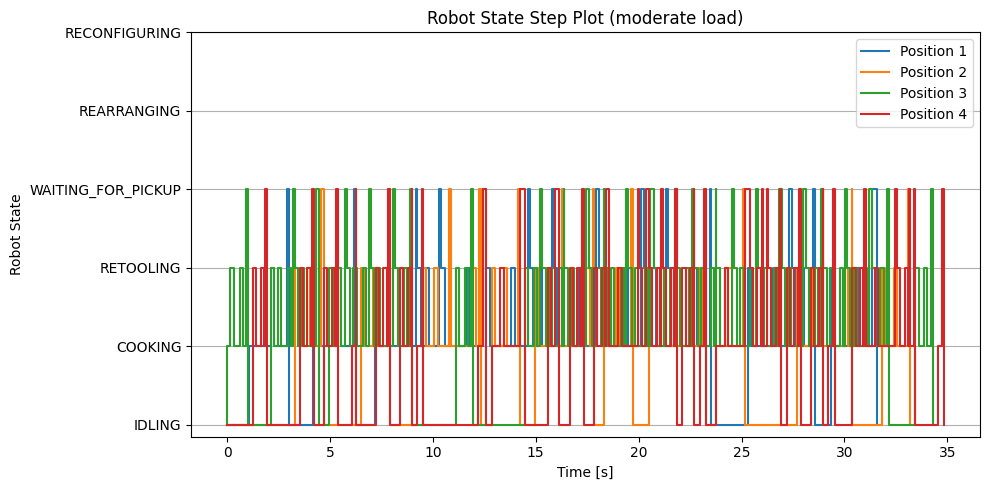

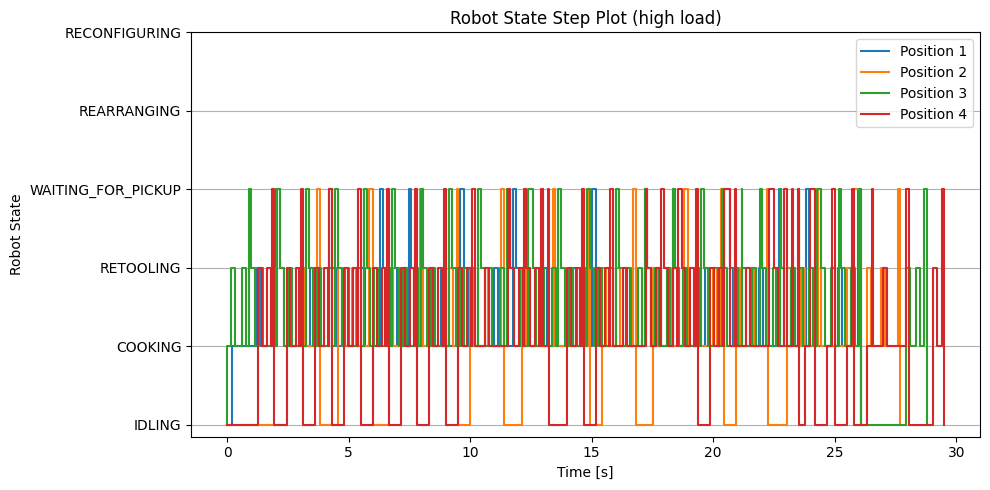

In [13]:
def plot_step_plot(statistics_df, title_addition):
    plt.figure(figsize=(10, 5))
    positions = sorted(statistics_df['Position'].unique().to_list())
    for pos in positions:
        pos_df = statistics_df.filter(pl.col('Position') == pos)
        plt.step(
            pos_df['Timestamp'].to_numpy() / 1e9,
            pos_df['State'].to_numpy(),
            where='post',
            label=f'Position {pos}'
        )

    # Map y-ticks to state names
    state_vals = sorted(ROBOT_STATE_NAME.keys())
    plt.yticks(state_vals, [ROBOT_STATE_NAME[v] for v in state_vals])

    plt.xlabel('Time [s]')
    plt.ylabel('Robot State')
    plt.title(f'Robot State Step Plot ({title_addition})')
    plt.grid(True, axis='y')
    plt.legend()
    plt.tight_layout()
    plt.show()

stat_dfs = [moderate_load_df, high_load_df]
titles = ['moderate load', 'high load']
for stat_df, title in zip(stat_dfs, titles):
    plot_step_plot(stat_df, title)